# Helper Functions

In [30]:
import numpy as np
import os
from nilearn import datasets

X = np.load('data/X_features.npy')
y_groups = np.load('data/y_labels.npy')
y_task = np.load('data/y_tasks.npy')
groups = np.load('data/subject_groups.npy')

def get_all_data():
    return X, y_groups, groups

def get_labels():
    atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
    labels = atlas.labels
    return labels

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
def plt_roc_curve(all_test_labels, all_test_probs, model_name="Model"):
    # 1. Convert lists to numpy arrays first
    labels_array = np.array(all_test_labels)
    probs_array = np.array(all_test_probs)

    # 2. Flatten them to ensure they are 1D (removes that extra dimension)
    labels_flat = labels_array.flatten()
    probs_flat = probs_array.flatten()

    # After the loop finishes:
    fpr, tpr, thresholds = roc_curve(labels_flat, probs_flat)
    roc_auc = auc(fpr, tpr)

    # Plotting
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'Receiver Operating Characteristic (ROC) - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Support Vector Machine SVM

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

labels = get_labels()

def svm_show_results_skf(X_avg, y_avg, groups, task_name):
    # 1. Define Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # Re-added probability=True so predict_proba() works in the loop
        ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42)) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    

    for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X, y_groups, groups=groups)):
        
        # Get the unique subject IDs in train and test for this fold
        train_subjects = set(groups[train_idx])
        test_subjects = set(groups[test_idx])
        
        # Check for leakage (Intersection should be an empty set)
        leakage = train_subjects.intersection(test_subjects)
        
        # Check label distribution to ensure stratification
        train_labels = y_groups[train_idx]
        test_labels = y_groups[test_idx]
        
        print(f"\nFold {fold_idx + 1}:")
        if len(leakage) == 0:
            print(f"  [PASS] Leakage Check: 0 subjects overlap.")
        else:
            print(f"  [FAIL] Leakage Check: {len(leakage)} subjects overlap! Overlapping IDs: {leakage}")
            
        print(f"  Test Subjects ({len(test_subjects)} total): {test_subjects}")
        print(f"  Train Class Distribution (TD : MLD) -> {np.sum(train_labels == 0)} : {np.sum(train_labels == 1)}")
        print(f"  Test Class Distribution  (TD : MLD) -> {np.sum(test_labels == 0)} : {np.sum(test_labels == 1)}")
        # Fit on training fold
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Predict on testing fold
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    # FIX: Use y_test_all here, NOT y_avg, so the shuffled indices match
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Weights)
    # Fit on the WHOLE dataset to get the final, stable model weights
    pipeline.fit(X_avg, y_avg)
    
    # FIX: Since SelectKBest is gone, we just grab all the weights directly from the SVM.
    weights = pipeline.named_steps['svm'].coef_[0]
    
    # Map to ROI pairs (Schaefer 100 uses upper triangle indices)
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Strongest Connections for {task_name}:")
    print(f"{'Brain Connection':<55} | {'Weight':<10}")
    print("-" * 70)

    # Sort by absolute weight value (largest to smallest)
    sorted_idx = np.argsort(np.abs(weights))[::-1]

    # Print the top 10 most influential brain connections
    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        # Clean labels and print
        connection_str = f"{name_a} <-> {name_b}"
        # Print the actual weight (with its positive/negative sign)
        print(f"{connection_str:<55} | {weights[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



Fold 1:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'007', '024', '057', '090', '069', '078'}
  Train Class Distribution (TD : MLD) -> 88 : 104
  Test Class Distribution  (TD : MLD) -> 32 : 16

Fold 2:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'008', '095', '070', '053', '036', '083'}
  Train Class Distribution (TD : MLD) -> 88 : 104
  Test Class Distribution  (TD : MLD) -> 32 : 16

Fold 3:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'010', '044', '088', '106', '067', '059'}
  Train Class Distribution (TD : MLD) -> 104 : 88
  Test Class Distribution  (TD : MLD) -> 16 : 32

Fold 4:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'096', '013', '027', '060', '071', '076'}
  Train Class Distribution (TD : MLD) -> 96 : 96
  Test Class Distribution  (TD : MLD) -> 24 : 24

Fold 5:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'065', '103', '075', '023', '034

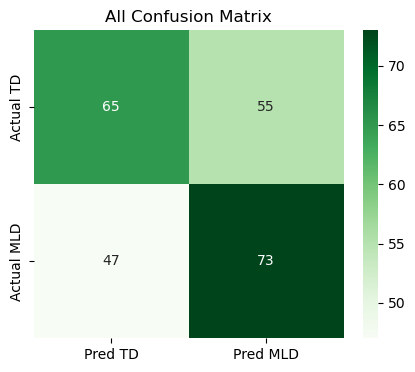


Top 10 Strongest Connections for All:
Brain Connection                                        | Weight    
----------------------------------------------------------------------
7Networks_LH_SalVentAttn_PFCl_1 <-> 7Networks_RH_DorsAttn_Post_3 | 0.0339
7Networks_LH_SomMot_1 <-> 7Networks_LH_SomMot_6         | -0.0298
7Networks_LH_Vis_8 <-> 7Networks_RH_Vis_8               | -0.0295
7Networks_LH_Vis_8 <-> 7Networks_RH_SomMot_2            | -0.0289
7Networks_LH_Default_Par_1 <-> 7Networks_RH_Default_Temp_1 | -0.0267
7Networks_RH_SomMot_7 <-> 7Networks_RH_Limbic_TempPole_1 | -0.0267
7Networks_LH_Cont_Cing_1 <-> 7Networks_RH_SalVentAttn_FrOperIns_1 | -0.0259
7Networks_LH_SalVentAttn_FrOperIns_2 <-> 7Networks_RH_Default_PFCdPFCm_1 | -0.0255
7Networks_LH_SalVentAttn_FrOperIns_1 <-> 7Networks_RH_SomMot_2 | -0.0253
7Networks_RH_Vis_6 <-> 7Networks_RH_Cont_pCun_1         | 0.0243


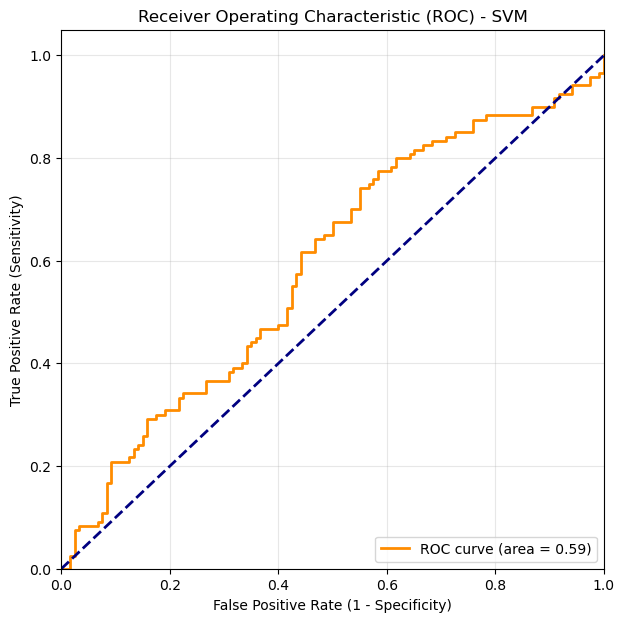

In [32]:
X, y, groups = get_all_data()
y_true, y_pred, y_probs = svm_show_results_skf(X, y, groups, "All")
plt_roc_curve(y_true, y_probs[:, 1], model_name="SVM")

# Multi Layer Perceptron MLP

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

labels = get_labels()

def mlp_show_results_skf(X_avg, y_avg, groups, task_name):
    # 1. Define Literature-Backed Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 16), # Funnel architecture for dimensionality reduction
            activation='relu',            
            solver='adam',                
            alpha=0.05,                   # Strong L2 regularization (Weight Decay)
            early_stopping=True,          
            validation_fraction=0.1,      
            max_iter=1000,                
            random_state=42
        )) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X, y_groups, groups=groups)):
        
        # Get the unique subject IDs in train and test for this fold
        train_subjects = set(groups[train_idx])
        test_subjects = set(groups[test_idx])
        
        # Check for leakage (Intersection should be an empty set)
        leakage = train_subjects.intersection(test_subjects)
        
        # Check label distribution to ensure stratification
        train_labels = y_groups[train_idx]
        test_labels = y_groups[test_idx]
        
        print(f"\nFold {fold_idx + 1}:")
        if len(leakage) == 0:
            print(f"  [PASS] Leakage Check: 0 subjects overlap.")
        else:
            print(f"  [FAIL] Leakage Check: {len(leakage)} subjects overlap! Overlapping IDs: {leakage}")
            
        print(f"  Test Subjects ({len(test_subjects)} total): {test_subjects}")
        print(f"  Train Class Distribution (TD : MLD) -> {np.sum(train_labels == 0)} : {np.sum(train_labels == 1)}")
        print(f"  Test Class Distribution  (TD : MLD) -> {np.sum(test_labels == 0)} : {np.sum(test_labels == 1)}")
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (MLP Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Changed to Blues to differentiate from the SVM's Greens
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} MLP Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Heuristic for MLP)
    pipeline.fit(X_avg, y_avg)
    
    # Extract weights from the Input Layer to the First Hidden Layer
    # Shape of coefs_[0] is (n_features, n_hidden_layer_1)
    W1 = pipeline.named_steps['mlp'].coefs_[0]
    
    # Heuristic: Sum the absolute values of the weights for each input feature 
    # across all neurons in the first hidden layer.
    feature_importances = np.sum(np.abs(W1), axis=1)
    
    # Map to ROI pairs
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Most Influential Connections for {task_name} (MLP W1-Norm Heuristic):")
    print(f"{'Brain Connection':<55} | {'Importance':<10}")
    print("-" * 70)

    # Sort by calculated importance value (largest to smallest)
    sorted_idx = np.argsort(feature_importances)[::-1]

    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        connection_str = f"{name_a} <-> {name_b}"
        print(f"{connection_str:<55} | {feature_importances[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



Fold 1:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'007', '024', '057', '090', '069', '078'}
  Train Class Distribution (TD : MLD) -> 88 : 104
  Test Class Distribution  (TD : MLD) -> 32 : 16

Fold 2:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'008', '095', '070', '053', '036', '083'}
  Train Class Distribution (TD : MLD) -> 88 : 104
  Test Class Distribution  (TD : MLD) -> 32 : 16

Fold 3:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'010', '044', '088', '106', '067', '059'}
  Train Class Distribution (TD : MLD) -> 104 : 88
  Test Class Distribution  (TD : MLD) -> 16 : 32

Fold 4:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'096', '013', '027', '060', '071', '076'}
  Train Class Distribution (TD : MLD) -> 96 : 96
  Test Class Distribution  (TD : MLD) -> 24 : 24

Fold 5:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'065', '103', '075', '023', '034

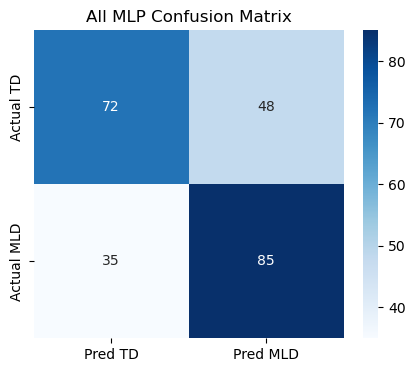


Top 10 Most Influential Connections for All (MLP W1-Norm Heuristic):
Brain Connection                                        | Importance
----------------------------------------------------------------------
7Networks_LH_DorsAttn_Post_3 <-> 7Networks_LH_Cont_PFCl_1 | 1.4156
7Networks_RH_Vis_4 <-> 7Networks_RH_Vis_5               | 1.4112
7Networks_RH_SomMot_1 <-> 7Networks_RH_Default_pCunPCC_1 | 1.4023
7Networks_LH_SalVentAttn_Med_1 <-> 7Networks_LH_Default_PFC_6 | 1.4012
7Networks_RH_SomMot_5 <-> 7Networks_RH_SomMot_8         | 1.3970
7Networks_LH_Vis_7 <-> 7Networks_RH_Cont_PFCl_1         | 1.3958
7Networks_LH_Default_Par_1 <-> 7Networks_RH_Vis_6       | 1.3925
7Networks_LH_Vis_6 <-> 7Networks_RH_Vis_6               | 1.3892
7Networks_LH_Vis_7 <-> 7Networks_RH_Limbic_OFC_1        | 1.3796
7Networks_RH_DorsAttn_Post_2 <-> 7Networks_RH_Limbic_OFC_1 | 1.3663


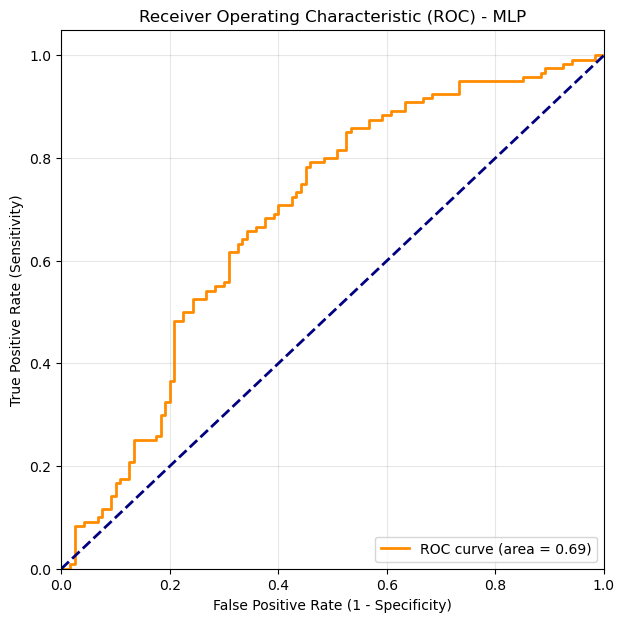

In [34]:
X_avg, y_avg, groups = get_all_data()
y_true, y_pred, y_probs = mlp_show_results_skf(X_avg, y_avg, groups, "All")
plt_roc_curve(y_true, y_probs[:, 1], model_name="MLP")

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

labels = get_labels()

def xgb_show_results_skf(X_avg, y_avg, groups, task_name):
    # 1. Define Literature-Backed Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(
            max_depth=3,              
            learning_rate=0.05,       
            n_estimators=100,         
            subsample=0.8,            
            colsample_bytree=0.1,     
            reg_alpha=1.0,            
            reg_lambda=1.0,           
            eval_metric='logloss',
            random_state=42
        )) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X, y_groups, groups=groups)):
        
        # Get the unique subject IDs in train and test for this fold
        train_subjects = set(groups[train_idx])
        test_subjects = set(groups[test_idx])
        
        # Check for leakage (Intersection should be an empty set)
        leakage = train_subjects.intersection(test_subjects)
        
        # Check label distribution to ensure stratification
        train_labels = y_groups[train_idx]
        test_labels = y_groups[test_idx]
        
        print(f"\nFold {fold_idx + 1}:")
        if len(leakage) == 0:
            print(f"  [PASS] Leakage Check: 0 subjects overlap.")
        else:
            print(f"  [FAIL] Leakage Check: {len(leakage)} subjects overlap! Overlapping IDs: {leakage}")
            
        print(f"  Test Subjects ({len(test_subjects)} total): {test_subjects}")
        print(f"  Train Class Distribution (TD : MLD) -> {np.sum(train_labels == 0)} : {np.sum(train_labels == 1)}")
        print(f"  Test Class Distribution  (TD : MLD) -> {np.sum(test_labels == 0)} : {np.sum(test_labels == 1)}")
        
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (XGBoost Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # Orange to visually separate from SVM and MLP
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} XGBoost Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Native to XGBoost)
    pipeline.fit(X_avg, y_avg)
    
    # XGBoost natively calculates the importance of each feature
    feature_importances = pipeline.named_steps['xgb'].feature_importances_
    
    # Map to ROI pairs
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Most Influential Connections for {task_name} (XGBoost Native Importance):")
    print(f"{'Brain Connection':<55} | {'Importance':<10}")
    print("-" * 70)

    # Sort by calculated importance value (largest to smallest)
    sorted_idx = np.argsort(feature_importances)[::-1]

    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        connection_str = f"{name_a} <-> {name_b}"
        print(f"{connection_str:<55} | {feature_importances[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



Fold 1:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'007', '024', '057', '090', '069', '078'}
  Train Class Distribution (TD : MLD) -> 88 : 104
  Test Class Distribution  (TD : MLD) -> 32 : 16

Fold 2:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'008', '095', '070', '053', '036', '083'}
  Train Class Distribution (TD : MLD) -> 88 : 104
  Test Class Distribution  (TD : MLD) -> 32 : 16

Fold 3:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'010', '044', '088', '106', '067', '059'}
  Train Class Distribution (TD : MLD) -> 104 : 88
  Test Class Distribution  (TD : MLD) -> 16 : 32

Fold 4:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'096', '013', '027', '060', '071', '076'}
  Train Class Distribution (TD : MLD) -> 96 : 96
  Test Class Distribution  (TD : MLD) -> 24 : 24

Fold 5:
  [PASS] Leakage Check: 0 subjects overlap.
  Test Subjects (6 total): {'065', '103', '075', '023', '034

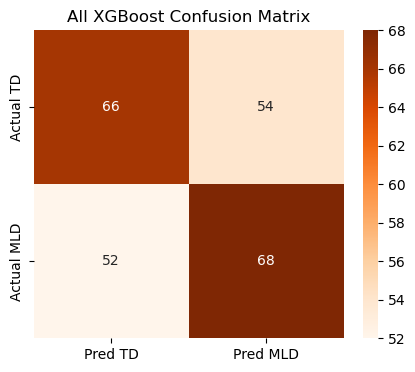


Top 10 Most Influential Connections for All (XGBoost Native Importance):
Brain Connection                                        | Importance
----------------------------------------------------------------------
7Networks_LH_SalVentAttn_ParOper_1 <-> 7Networks_LH_Default_PFC_4 | 0.0118
7Networks_LH_SalVentAttn_FrOperIns_1 <-> 7Networks_LH_Default_Par_2 | 0.0115
7Networks_LH_SalVentAttn_Med_2 <-> 7Networks_RH_SomMot_2 | 0.0109
7Networks_LH_SomMot_6 <-> 7Networks_LH_Default_PFC_6    | 0.0098
7Networks_LH_DorsAttn_Post_2 <-> 7Networks_LH_SalVentAttn_Med_1 | 0.0098
7Networks_LH_SomMot_2 <-> 7Networks_LH_Default_PFC_7    | 0.0095
Background <-> 7Networks_RH_Cont_PFCl_1                 | 0.0088
7Networks_LH_Vis_8 <-> 7Networks_RH_DorsAttn_Post_1     | 0.0086
7Networks_LH_SalVentAttn_ParOper_1 <-> 7Networks_RH_Cont_PFCl_1 | 0.0086
7Networks_LH_Limbic_OFC_1 <-> 7Networks_RH_Limbic_TempPole_1 | 0.0084


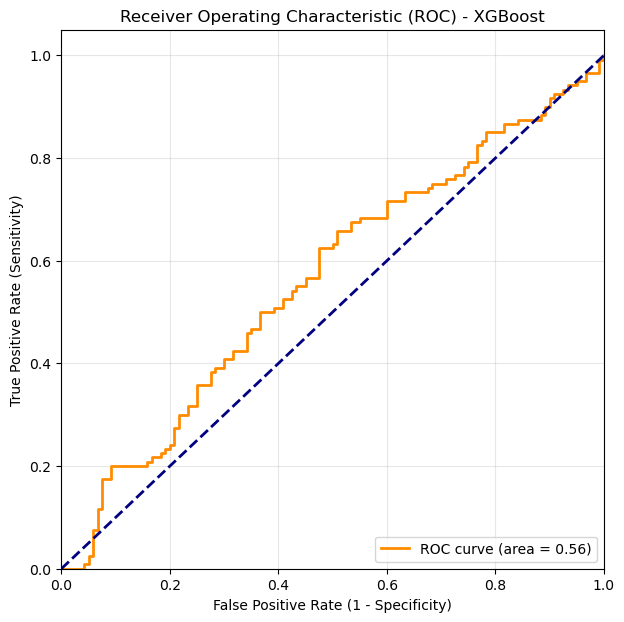

In [36]:
X_avg, y_avg, groups = get_all_data()
y_true, y_pred, y_probs = xgb_show_results_skf(X_avg, y_avg, groups, "All")
plt_roc_curve(y_true, y_probs[:, 1], model_name="XGBoost")